In [1]:
#HI2453_Final Project_Tarique
#Exploring Risk Factors and Predictive Characteristics in Alzheimer’s Disease Diagnosis: A Data Analytics and Machine Learning Approach.

# Uploading data file

from google.colab import files
uploaded = files.upload()

Saving alzheimers_disease_data.csv to alzheimers_disease_data.csv


In [2]:
# Reaading the file
import pandas as pd
import numpy as np
df = pd.read_csv('alzheimers_disease_data.csv')
print("Shape:", df.shape)
print("\nColumn types:")
print(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())

Shape: (2149, 35)

Column types:
PatientID                      int64
Age                            int64
Gender                         int64
Ethnicity                      int64
EducationLevel                 int64
BMI                          float64
Smoking                        int64
AlcoholConsumption           float64
PhysicalActivity             float64
DietQuality                  float64
SleepQuality                 float64
FamilyHistoryAlzheimers        int64
CardiovascularDisease          int64
Diabetes                       int64
Depression                     int64
HeadInjury                     int64
Hypertension                   int64
SystolicBP                     int64
DiastolicBP                    int64
CholesterolTotal             float64
CholesterolLDL               float64
CholesterolHDL               float64
CholesterolTriglycerides     float64
MMSE                         float64
FunctionalAssessment         float64
MemoryComplaints               int64
Behav

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


# **Exploratory Data analysis**

In [3]:
# Exploratory data analysis
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Missing value counts
print("\n Missing Values Per Column:")
missing_count = df.isnull().sum()
print(missing_count)

#  missing value percentages
print("\n Missing Value Percentage:")
missing_percent = (df.isnull().sum() / len(df)) * 100
print(missing_percent)

# Dropping irrelevant columns
df_cleaned = df.drop(columns=["PatientID", "DoctorInCharge"])

# Dropping rows with missing values
df_cleaned = df_cleaned.dropna()

# Normalizing BMI and MMSE using Min-Max scaling
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_cleaned[['BMI', 'MMSE']] = scaler.fit_transform(df_cleaned[['BMI', 'MMSE']])

# Convert Diagnosis to integer (Target)
df_cleaned['Diagnosis'] = df_cleaned['Diagnosis'].astype(int)

# Diagnosis distribution
diagnosis_distribution = df_cleaned['Diagnosis'].value_counts(normalize=True)
print("\nDiagnosis Distribution (Proportion):")
print(diagnosis_distribution)


 Missing Values Per Column:
PatientID                    0
Age                          0
Gender                       0
Ethnicity                    0
EducationLevel               0
BMI                          0
Smoking                      0
AlcoholConsumption           0
PhysicalActivity             0
DietQuality                  0
SleepQuality                 0
FamilyHistoryAlzheimers      0
CardiovascularDisease        0
Diabetes                     0
Depression                   0
HeadInjury                   0
Hypertension                 0
SystolicBP                   0
DiastolicBP                  0
CholesterolTotal             0
CholesterolLDL               0
CholesterolHDL               0
CholesterolTriglycerides     0
MMSE                         0
FunctionalAssessment         0
MemoryComplaints             0
BehavioralProblems           0
ADL                          0
Confusion                    0
Disorientation               0
PersonalityChanges           0
Difficulty

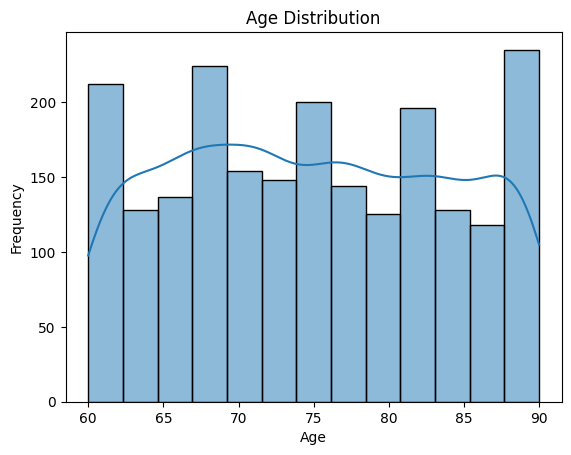

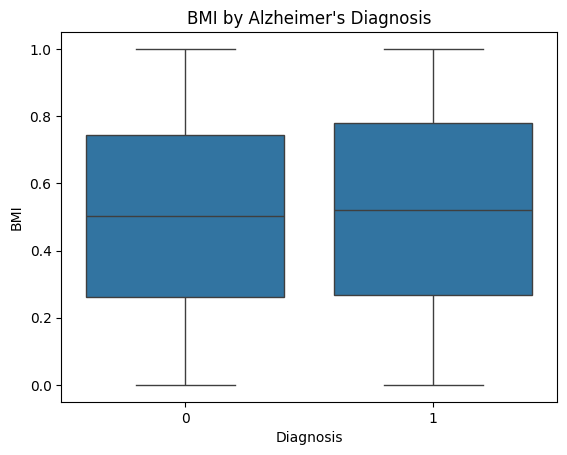

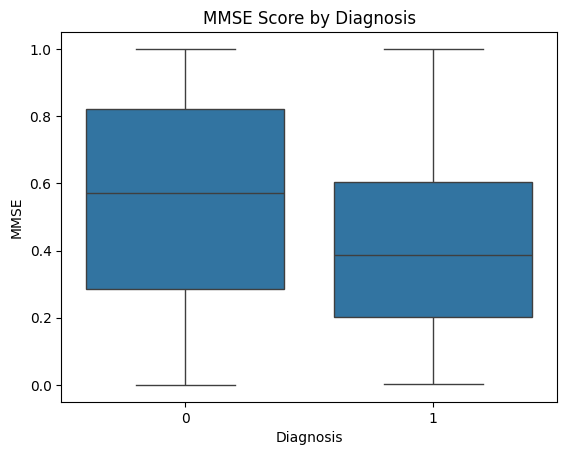

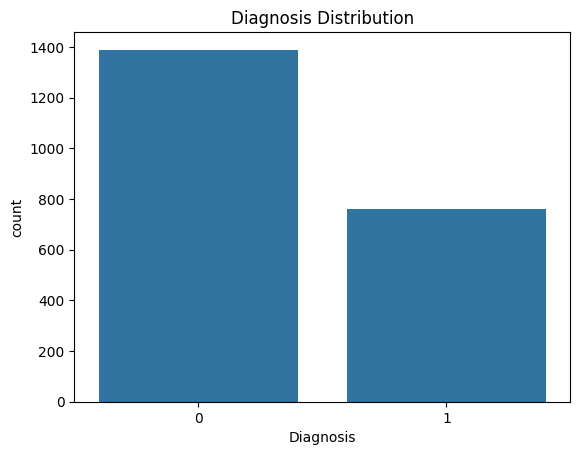

In [4]:
# Distribution visualization and correlation
import seaborn as sns
import matplotlib.pyplot as plt

# Distribution of Age
sns.histplot(df_cleaned['Age'], kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# Boxplot: BMI by Diagnosis
sns.boxplot(x='Diagnosis', y='BMI', data=df_cleaned)
plt.title("BMI by Alzheimer's Diagnosis")
plt.show()

# Boxplot: MMSE by Diagnosis
sns.boxplot(x='Diagnosis', y='MMSE', data=df_cleaned)
plt.title("MMSE Score by Diagnosis")
plt.show()

# Bar chart: Diagnosis counts
sns.countplot(x='Diagnosis', data=df_cleaned)
plt.title("Diagnosis Distribution")
plt.show()




Optimization terminated successfully.
         Current function value: 0.619228
         Iterations 5
                            Coef.         P>|z|
Intercept                0.410970  3.791761e-01
Age                     -0.002028  6.962252e-01
Gender                  -0.065720  4.810271e-01
EducationLevel          -0.090264  8.065855e-02
BMI                      0.007611  2.382383e-01
Smoking                 -0.032796  7.506395e-01
AlcoholConsumption      -0.004198  6.039969e-01
PhysicalActivity         0.001610  9.214616e-01
MMSE                    -0.059793  9.160395e-27
FamilyHistoryAlzheimers -0.148855  1.708341e-01
Depression              -0.004689  9.679469e-01


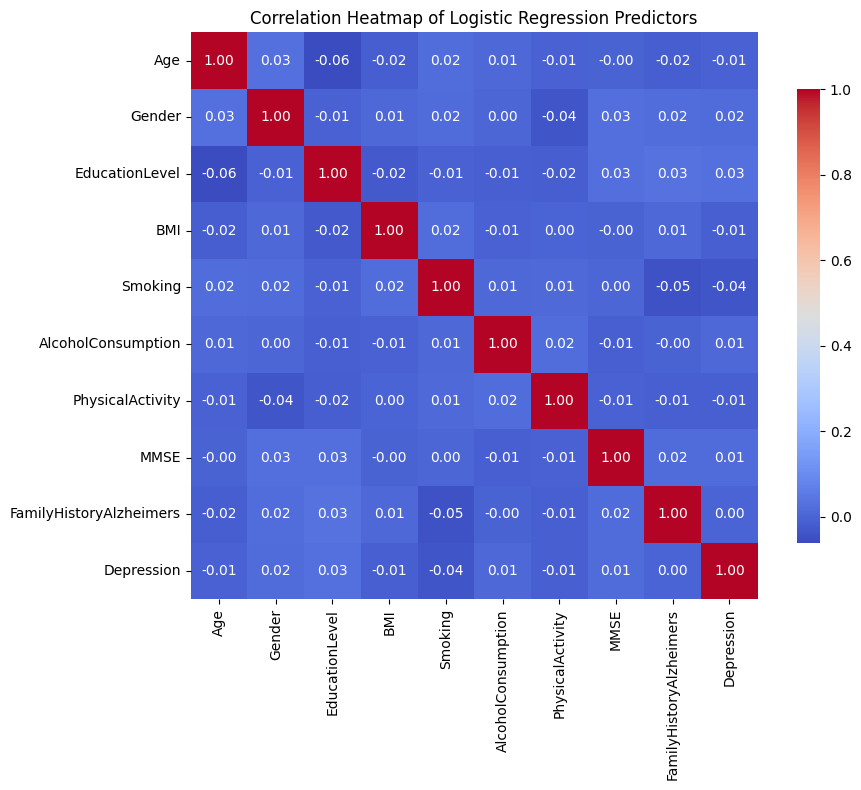

In [5]:
# Define predictors

from scipy.stats import ttest_ind
import pandas as pd
import statsmodels.formula.api as smf

# Define predictors
predictors = [
    'Age', 'Gender', 'EducationLevel', 'BMI', 'Smoking',
    'AlcoholConsumption', 'PhysicalActivity', 'MMSE',
    'FamilyHistoryAlzheimers', 'Depression'
]

# Create formula for statsmodels
formula = 'Diagnosis ~ ' + ' + '.join(predictors)

# Fit logistic regression
logit_model = smf.logit(formula=formula, data=df).fit()

# Show summary of coefficients and p-values
print(logit_model.summary2().tables[1][['Coef.', 'P>|z|']])

# Calculate correlation matrix for logistic regression predictors
correlation_matrix = df_cleaned[[
    'Age', 'Gender', 'EducationLevel', 'BMI', 'Smoking',
    'AlcoholConsumption', 'PhysicalActivity', 'MMSE',
    'FamilyHistoryAlzheimers', 'Depression'
]].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={'shrink': 0.8})
plt.title("Correlation Heatmap of Logistic Regression Predictors")
plt.tight_layout()
plt.show()

Diagnosis counts:
Diagnosis
0    1389
1     760
Name: count, dtype: int64

Diagnosis percentages (%):
Diagnosis
0    64.63
1    35.37
Name: count, dtype: float64


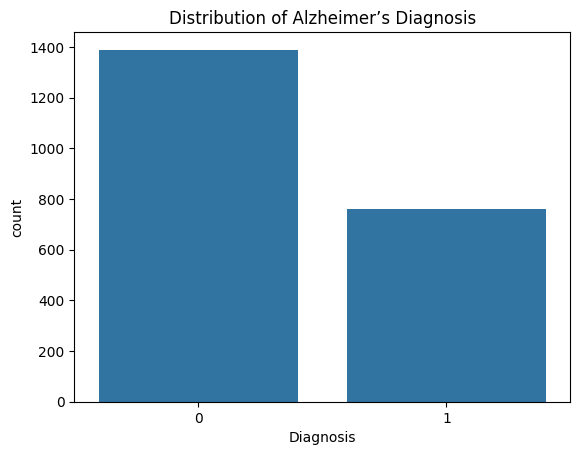

Age          BMI         MMSE       FunctionalAssessment        \
            mean   std   mean   std   mean   std                 mean   std   
Diagnosis                                                                     
0          74.95  8.90  27.52  7.17  16.27  8.93                 5.86  2.76   
1          74.84  9.15  27.91  7.30  11.99  7.23                 3.65  2.57   

            ADL       CholesterolTotal        SystolicBP        DiastolicBP  \
           mean   std             mean    std       mean    std        mean   
Diagnosis                                                                     
0          5.71  2.83           225.00  42.20     134.56  25.95       89.78   
1          3.66  2.70           225.57  43.19     133.72  25.96       89.97   

                  
             std  
Diagnosis         
0          17.67  
1          17.46

In [6]:
# Diagnosis distribution (class balance)
diag_counts = df["Diagnosis"].value_counts().sort_index()
diag_percent = (diag_counts / len(df) * 100).round(2)

print("Diagnosis counts:")
print(diag_counts)
print("\nDiagnosis percentages (%):")
print(diag_percent)

sns.countplot(x="Diagnosis", data=df)
plt.title("Distribution of Alzheimer’s Diagnosis")
plt.show()

# Group means for key continuous variables
key_cont = ["Age", "BMI", "MMSE", "FunctionalAssessment", "ADL",
            "CholesterolTotal", "SystolicBP", "DiastolicBP"]

group_desc = df.groupby("Diagnosis")[key_cont].agg(["mean", "std"]).round(2)
group_desc

## **Feature Engineering**

In [7]:
# Defining base feature sets
target = "Diagnosis"


base_features = [c for c in df.columns if c != target]
numeric_features = [
    "Age", "BMI", "SystolicBP", "DiastolicBP",
    "CholesterolTotal", "CholesterolLDL",
    "CholesterolHDL", "CholesterolTriglycerides",
    "MMSE", "FunctionalAssessment", "ADL"
]

binary_or_ordinal = [
    "Gender", "Ethnicity", "EducationLevel",
    "Smoking", "AlcoholConsumption",
    "PhysicalActivity", "DietQuality", "SleepQuality",
    "FamilyHistoryAlzheimers", "CardiovascularDisease",
    "Diabetes", "Depression", "HeadInjury", "Hypertension",
    "MemoryComplaints", "BehavioralProblems",
    "Confusion", "Disorientation", "PersonalityChanges",
    "DifficultyCompletingTasks", "Forgetfulness"
]

print("Unassigned features (should be empty or very small):")
set(base_features) - set(numeric_features) - set(binary_or_ordinal)


Unassigned features (should be empty or very small):


{'DoctorInCharge', 'PatientID'}

In [8]:
# Coverting BMI Categories into normal/overwieght/obese

def bmi_category(bmi):
    if pd.isnull(bmi):
        return np.nan
    if bmi < 25:
        return "normal"
    elif bmi < 30:
        return "overweight"
    else:
        return "obese"

df["BMI_category"] = df["BMI"].apply(bmi_category)
df["BMI_category"].value_counts(dropna=False)

,count
BMI_category,
obese,871
normal,841
overweight,437


In [9]:
# Summing key variables into Comorbidty Index
comorb_cols = ["Hypertension", "CardiovascularDisease", "Diabetes", "Depression"]
df["ComorbidityIndex"] = df[comorb_cols].sum(axis=1)

df["ComorbidityIndex"].describe()


,ComorbidityIndex
count,2149.000000
mean,0.644486
std,0.738155
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,4.000000


In [10]:
# Creating Cognitive impairment flag for MMSE below cut-off <24
# Example MMSE cutoff for dementia level impairment
df["CognitiveImpairmentFlag"] = (df["MMSE"] < 24).astype(int)

df["CognitiveImpairmentFlag"].value_counts()

,count
CognitiveImpairmentFlag,
1,1734
0,415


In [11]:
#Final Feature List
categorical_features = ["BMI_category"]
extra_numeric = ["ComorbidityIndex", "CognitiveImpairmentFlag"]

numeric_features_full = numeric_features + extra_numeric
all_model_features = numeric_features_full + binary_or_ordinal + categorical_features

X = df[all_model_features]
y = df[target]

X.shape, y.shape

((2149, 35), (2149,))

## **Train/Test split and preprocessing**

In [12]:
# Training

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1719, 35), (430, 35), (1719,), (430,))

In [13]:
# Column Transformer

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

numeric_for_impute_scale = numeric_features_full
categorical_for_onehot = categorical_features

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

binary_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_for_impute_scale),
        ("bin", binary_transformer, binary_or_ordinal),
        ("cat", categorical_transformer, categorical_for_onehot)
    ]
)

In [14]:
# Preprocessing
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

# Get feature names
feature_names_num = numeric_features_full
feature_names_bin = binary_or_ordinal
feature_names_cat = list(
    preprocessor.named_transformers_["cat"]["onehot"]
    .get_feature_names_out(categorical_features)
)
feature_names_all = feature_names_num + feature_names_bin + feature_names_cat

# Convert to DataFrame (dense guaranteed)
X_train_proc = pd.DataFrame(X_train_proc, columns=feature_names_all)
X_test_proc = pd.DataFrame(X_test_proc, columns=feature_names_all)

print(f"Processed features: {X_train_proc.shape[1]}")

Processed features: 36


### **Feature Selection**

In [15]:
# Anova F-Test
from sklearn.feature_selection import f_classif
from sklearn.linear_model import LogisticRegressionCV
# Filter: F-test
F_vals, p_vals = f_classif(X_train_proc, y_train)
filter_results = pd.DataFrame({
    "Feature": feature_names_all,
    "F_value": F_vals,
    "p_value": p_vals
}).sort_values("p_value").head(15)
print("TOP F-TEST FEATURES")
print(filter_results)



TOP F-TEST FEATURES
                     Feature     F_value       p_value
9       FunctionalAssessment  257.318763  4.569455e-54
10                       ADL  219.327424  8.599644e-47
27          MemoryComplaints  199.616266  5.852884e-43
12   CognitiveImpairmentFlag  176.244987  2.321970e-38
8                       MMSE  101.512032  3.096540e-23
28        BehavioralProblems   79.965086  9.617548e-19
20              SleepQuality    5.240384  2.218930e-02
6             CholesterolHDL    4.667156  3.088277e-02
22     CardiovascularDisease    3.306843  6.916608e-02
2                 SystolicBP    3.168299  7.525739e-02
7   CholesterolTriglycerides    2.863362  9.079937e-02
31        PersonalityChanges    2.680096  1.017929e-01
15            EducationLevel    2.465476  1.165567e-01
23                  Diabetes    1.972211  1.603942e-01
21   FamilyHistoryAlzheimers    1.881800  1.703089e-01


In [16]:
# Lasso Regression

from sklearn.linear_model import LogisticRegressionCV

lasso = LogisticRegressionCV(
    Cs=10,
    cv=5,
    penalty="l1",
    solver="liblinear",
    scoring="roc_auc",
    max_iter=500

)
lasso.fit(X_train_proc, y_train)

coef_series = pd.Series(lasso.coef_[0], index=feature_names_all)
lasso_importance = coef_series.reindex(coef_series.abs().sort_values(ascending=False).index)
lasso_importance.head(20)


,0
MemoryComplaints,3.199978
BehavioralProblems,3.016698
CognitiveImpairmentFlag,1.804947
FunctionalAssessment,-1.507566
ADL,-1.434464
Age,-0.141908
CholesterolLDL,-0.125390
CholesterolHDL,0.114104
EducationLevel,-0.113103
SleepQuality,-0.099896


In [17]:
# Random Forest and XGboost imortance

from sklearn.ensemble import RandomForestClassifier
rf_fs = RandomForestClassifier(
    n_estimators=200, random_state=42, n_jobs=-1,
    class_weight="balanced_subsample"
).fit(X_train_proc, y_train)
rf_importance = pd.Series(rf_fs.feature_importances_, index=X_train_proc.columns).sort_values(ascending=False)
print("\n TOP RF FEATURES ")
print(rf_importance.head(10))





 TOP RF FEATURES 
FunctionalAssessment       0.187502
ADL                        0.164248
MemoryComplaints           0.096785
MMSE                       0.095944
BehavioralProblems         0.051954
CognitiveImpairmentFlag    0.051821
DietQuality                0.027104
CholesterolHDL             0.026284
BMI                        0.026178
SleepQuality               0.025832
dtype: float64


In [18]:
# XGBoost
from xgboost import XGBClassifier
xgb_fs = XGBClassifier(
    n_estimators=200, random_state=42, n_jobs=-1,
    scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1])
).fit(X_train_proc, y_train)
xgb_importance = pd.Series(xgb_fs.feature_importances_, index=X_train_proc.columns).sort_values(ascending=False)
print("\n TOP XGB FEATURES ")
print(xgb_importance.head(10))



 TOP XGB FEATURES 
BehavioralProblems         0.160108
MemoryComplaints           0.159465
FunctionalAssessment       0.098964
ADL                        0.082723
MMSE                       0.081295
Confusion                  0.032899
Smoking                    0.027317
ComorbidityIndex           0.027207
BMI_category_overweight    0.024870
PersonalityChanges         0.023216
dtype: float32


In [19]:
# Consensus selection (top 25 from each method)
top_k = 25
top_lasso = set(lasso_importance.head(top_k).index)
top_rf = set(rf_importance.head(top_k).index)
top_xgb = set(xgb_importance.head(top_k).index)

consensus_features = (top_lasso & top_rf) | (top_lasso & top_xgb) | (top_rf & top_xgb)
X_train_sel = X_train_proc[list(consensus_features)]
X_test_sel = X_test_proc[list(consensus_features)]

print(f"\nConsensus features selected: {len(consensus_features)}")
print("Sample consensus features:", list(consensus_features)[:10])


Consensus features selected: 26
Sample consensus features: ['MMSE', 'CholesterolLDL', 'Ethnicity', 'Confusion', 'BMI', 'PhysicalActivity', 'FunctionalAssessment', 'CholesterolHDL', 'MemoryComplaints', 'CholesterolTotal']


### **Model Evaluation**

In [25]:
#Model evaluation
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

def evaluate_model(model, name, X_train, X_test, y_train, y_test):
    # Train model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    if name == "SVM":
        y_proba = model.decision_function(X_test)
    else:
        y_proba = model.predict_proba(X_test)[:, 1]

    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    }

    print(f"\n{'='*50}")
    print(f"{name:^50}")
    print(f"{'='*50}")
    for metric, value in metrics.items():
        print(f"{metric:12}: {value:.3f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    return metrics


# Defining model
final_models = {
    'LogisticRegression': LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    'RandomForest': RandomForestClassifier(n_estimators=400, max_depth=6, random_state=42, n_jobs=-1, class_weight='balanced_subsample'),
    'XGBoost': XGBClassifier(n_estimators=400, max_depth=4, learning_rate=0.05, random_state=42, n_jobs=-1),
    'SVM': SVC(probability=True, class_weight='balanced', random_state=42)
}

# Runing models
results = {}
for name, model in final_models.items():
    results[name] = evaluate_model(model, name, X_train_sel, X_test_sel, y_train, y_test)



                LogisticRegression                
Accuracy    : 0.884
Precision   : 0.797
Recall      : 0.901
F1          : 0.846
ROC-AUC     : 0.933

Confusion Matrix:
[[243  35]
 [ 15 137]]

                   RandomForest                   
Accuracy    : 0.956
Precision   : 0.946
Recall      : 0.928
F1          : 0.937
ROC-AUC     : 0.946

Confusion Matrix:
[[270   8]
 [ 11 141]]

                     XGBoost                      
Accuracy    : 0.942
Precision   : 0.938
Recall      : 0.895
F1          : 0.916
ROC-AUC     : 0.944

Confusion Matrix:
[[269   9]
 [ 16 136]]

                       SVM                        
Accuracy    : 0.842
Precision   : 0.733
Recall      : 0.868
F1          : 0.795
ROC-AUC     : 0.922

Confusion Matrix:
[[230  48]
 [ 20 132]]


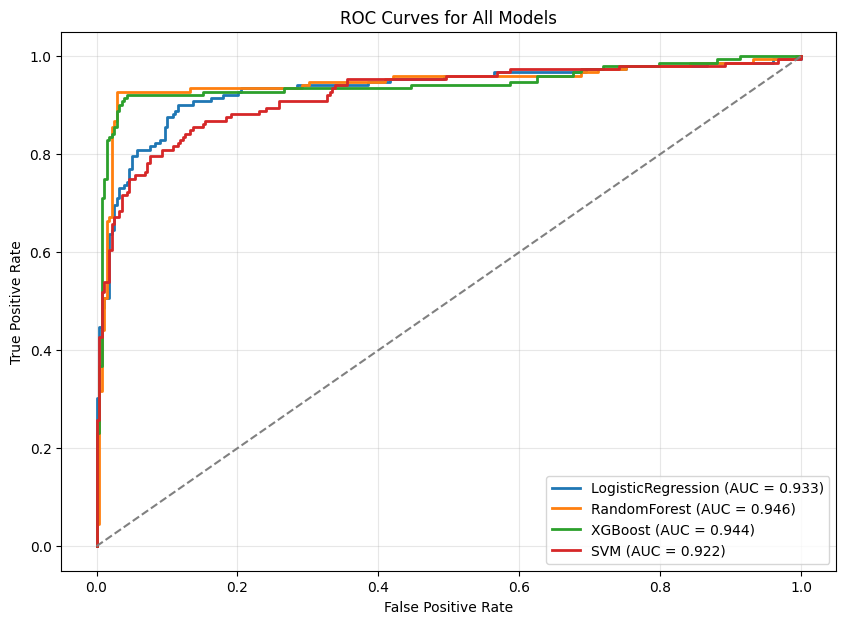

In [26]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

for name, model in final_models.items():

    if name == "SVM":
        y_score = model.decision_function(X_test_sel)
    else:
        y_score = model.predict_proba(X_test_sel)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for All Models")
plt.legend()
plt.grid(alpha=0.3)
plt.show()